In [59]:
print("all ok")

all ok


In [60]:
from dotenv import load_dotenv

In [61]:
load_dotenv(override=True)

True

In [62]:
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

In [63]:
# llm=ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct")
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

In [64]:
print(llm.invoke("What is the capital of France?").content)

The capital of France is Paris.


In [7]:
print(llm.invoke("What is the capital of india tell me in detail?").content)

The capital of India is New Delhi. It serves as the seat of all three branches of the government of India, hosting the Rashtrapati Bhavan (Presidential Residence), the Parliament of India, and the Supreme Court of India. New Delhi is part of the larger National Capital Territory of Delhi (NCT), which is a unique union territory that includes the city of Delhi and its surrounding areas.

New Delhi was officially declared the capital of India in 1931, replacing Calcutta (now Kolkata) during the British colonial period. The city was designed by British architects Sir Edwin Lutyens and Sir Herbert Baker, and it is known for its wide boulevards, colonial architecture, and numerous national institutions and landmarks.

Some notable landmarks in New Delhi include India Gate, a war memorial; the Rashtrapati Bhavan, the official residence of the President of India; and the Parliament House. The city is also home to several cultural and historical sites, such as the Qutub Minar, Humayun's Tomb, 

In [65]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [66]:
search_tool.invoke("What is the capital of France?")

[{'title': 'List of capitals of France - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/List_of_capitals_of_France',
  'content': 'This is a chronological list of capitals of France. The capital of France has been Paris since its liberation in 1944.\n\n## Chronology\n\n[edit] [...] Tours (10–13 June 1940), the city served as the temporary capital of France during World War II after the government fled Paris due to the German advance.\n Bordeaux (June 1940), the government was relocated from Paris to Tours then Bordeaux very briefly during World War II, when it became apparent that Paris would soon fall into German hands. [...] Paris (1789–1871), on 5 and 6 October 1789, a throng from Paris invaded the castle and forced the royal family to move back to Paris. The National Constituent Assembly "National Constituent Assembly (France)") followed the King to Paris soon afterward; Versailles lost its role of capital city.',
  'score': 0.8993429},
 {'title': 'Paris facts: the capital of 

In [67]:
my_code = """
x=10
y=x+10
print(y)
"""

In [68]:
from langchain_experimental.utilities import PythonREPL

In [69]:
repl=PythonREPL()

In [70]:
repl.run(my_code)

'20\n'

In [71]:
repl.invoke(my_code)

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [72]:
from typing import Annotated

In [73]:
from langchain_core.tools import tool

In [129]:
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate your chart."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    print(result)
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {float(result) + 2} "
    return result_str

<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
<>:11: SyntaxWarning: invalid escape sequence '\`'
C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\4018003995.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {float(result) + 2} "
C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\4018003995.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {float(result) + 2} "


In [130]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)")

'Successfully executed:\n\\`\\`\\`python\nx=10\ny=x+10\nprint(y)\n\\`\\`\\`\nStdout: 22.0 '

In [127]:
python_repl_tool.invoke(my_code)

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\539818153.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result + 2} "
C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\539818153.py:11: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result + 2} "


TypeError: can only concatenate str (not "int") to str

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [20]:
members=["researcher","coder"]

In [21]:
members

['researcher', 'coder']

In [78]:
options = members+["FINISH"]

In [79]:
options

['researcher', 'coder', 'FINISH']

In [80]:
from typing import Literal

In [81]:
from typing_extensions import TypedDict

## There is no routing logic
### it is simply going to return the next candidate(next_agent)
### this next is containig the next candidate name

In [26]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [82]:
from langgraph.graph import MessagesState,StateGraph,START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

#### this is a messagesstate which we are loading from the langgraph(inbuilt message state)

In [28]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
class State(MessagesState):
    next:str
    researcher_iter_count:int

##### this is how my state will be looking like

In [84]:
class State(MessagesState):
    next:str
state={"messages": ["hi"], "next": "research_agent"}

In [85]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [32]:
# system_prompt = f""""
# You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
# Given the following user request, respond with the worker to act next. 
# Each worker will perform a task and respond with their results and status. 
# When finished, respond with FINISH.
# **Strict Guidelines:**
# if there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.
# """

In [33]:
# system_prompt = f"""
# You are a supervisor managing a task delegation system with the following workers: {members}.

# Your job is to decide which worker should act next based on the user’s input.

# Guidelines:
# - Carefully read the user’s message.
# - If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
# - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
# - Do **not** invent tasks or assign actions unless the message clearly demands it.

# Each worker will return results after completing their task.
# Once all necessary tasks are completed, end the flow by responding with `FINISH`.

# Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
# """


In [86]:
print(system_prompt)

"
You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder']. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.



In [87]:
state

{'messages': ['hi'], 'next': 'research_agent'}

In [88]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [89]:
messages

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n'},
 'hi']

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n**Strict Guidelines:**\nif there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.\n'},
 'hi']

In [ ]:
llm_with_structure_output=llm.with_structured_output(Router)

In [ ]:
dir(llm_with_structure_output)

['InputType',
 'OutputType',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__class_vars__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__fields__',
 '__fields_set__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__get_pydantic_core_schema__',
 '__get_pydantic_json_schema__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__orig_bases__',
 '__parameters__',
 '__pretty__',
 '__private_attributes__',
 '__pydantic_complete__',
 '__pydantic_computed_fields__',
 '__pydantic_core_schema__',
 '__pydantic_custom_init__',
 '__pydantic_decorators__',
 '__pydantic_extra__',
 '__pydantic_fields__',
 '__pydantic_fields_set__',
 '__pydantic_generic_metadata__',
 '__pydantic_init_subclass__',
 '__pydantic_parent_namespace__',
 '__pydantic_post_init__',
 '__pydan

In [92]:
llm_with_structure_output

RunnableBinding(bound=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x0000028E5FF10B90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000028E5FF10A50>, root_client=<openai.OpenAI object at 0x0000028E5FF107D0>, root_async_client=<openai.AsyncOpenAI object at 0x0000028E5FF10E10>, model_name='gpt-4o', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********')), kwargs={'response_format': {'type': 'json_schema', 'json_schema': {'name': 'Router', 'description': "dict() -> new empty dictionary\ndict(mapping) -> new dictionary initialized from a mapping object's\n    (key, value) pairs\ndict(iterable) -> new dictionary initialized as if via:\n    d = {}\n    for k, v in iterable:\n        d[k] = v\ndict(**kwargs) -> new dictionary initialized with the name=value pairs\n    in the keyword argument list.  For example:  dict(one=1, two=2)", 'strict': False, 'schema': {'type': 'object', 'properties

In [93]:
llm_with_structure_output.invoke(messages)

{'next': 'researcher'}

#### This is my all three agents

In [94]:
from langgraph.types import Command

In [131]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]:
    
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    llm_with_structure_output=llm.with_structured_output(Router)
    
    response=llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'}
    
    #this is my next worker agent
    goto=response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH":
        goto=END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    
    return Command(goto=goto, update={"next":goto," researcher_iter_count": state.get("researcher_iter_count",0)})

In [132]:
from langgraph.prebuilt import create_react_agent

In [133]:
from langchain_core.messages import AIMessage, HumanMessage

In [134]:
def research_agent(state: State) -> Command[Literal["supervisor"]]:
    
    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result=research_agent.invoke(state)
    print("-"*100)
    print(result)
    print("-"*100)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )
    

In [135]:
def coder_agent(state:State)->Command[Literal['supervisor']]:
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )
    

#### this is my orchestration flow with langgraph

In [136]:
graph=StateGraph(State)

In [137]:
graph.add_node("supervisor", supervisor_agent)

In [138]:
graph.add_node("researcher", research_agent)

In [139]:
graph.add_node("coder", coder_agent)

In [140]:
graph.add_edge(START, "supervisor")

In [141]:
app=graph.compile()

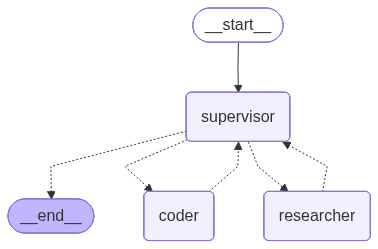

In [142]:
app

In [143]:
from IPython.display import display,Image

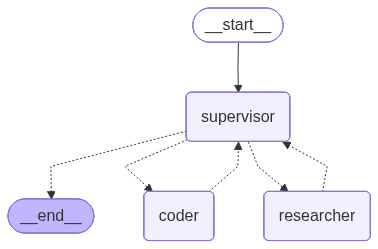

In [144]:
display(Image(app.get_graph().draw_mermaid_png()))

In [145]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
coder
((), {'supervisor': {'next': 'coder'}})
**********BELOW IS MY STATE***************


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:18cbd0fc-f920-b874-7e81-dc9b2922d222',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_KwBh1I6amj3pJDlc5V4J6q70', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 107, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CZV55qw24U1lab1NqZITDsaGl1R7A', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--de7bdf5a-6f49-433c-b12a-17232e46acd7-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_KwBh1I6amj3pJDlc5V4J6q70', 'type':

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:d964f26c-22b1-a0e1-60b1-cdf2e620a8e6',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_0xewNi93WH72UpEQlg3mncGI', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 126, 'total_tokens': 149, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CZV59Z9vREjo6mZbsBgeKYHfxccuX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--a405f355-b1a4-44d7-b0cb-5251872c2cab-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_0xewNi93WH72UpEQlg3mncGI', 'type':

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\3496100515.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


----------------------------------------------------------------------------------------------------(('researcher:a0f1e68e-082a-8ab3-f12a-6e5e4def1a45',), {'agent': {'messages': [AIMessage(content='I apologize for the confusion earlier. I recommend using a calculator or a computational tool to find the precise square root of 42.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 152, 'total_tokens': 179, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CZV5B8RxNQef9JUMsopQNfcrnEVBu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--62db5f5f-4bac-4b73-9c0b-3b188b0d260c-0', usage_metadata={'input_tokens': 152, 'output_tokens': 27, 'total_tokens': 179,

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:47bbb4f1-e249-920f-69cf-fafe38a7b21b',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_3looLN8mMRNT4oHtRT4NMjdh', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 194, 'total_tokens': 217, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CZV5D4V5eMpthI684XpDX6pxaATOv', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d7d8102b-211f-443d-a231-57bb97bba060-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_3looLN8mMRNT4oHtRT4NMjdh', 'type':

In [118]:
s

((), {'supervisor': {'next': '__end__'}})

In [120]:
result = app.invoke({"messages": [("user", "What's the square root of 42?")]})

**********BELOW IS MY GOTO***************
coder


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [124]:
result

{'messages': [HumanMessage(content="What's the square root of 42?", additional_kwargs={}, response_metadata={}, id='b6557e1d-b149-4129-8008-70492d64fedf'),
  HumanMessage(content='The square root of 42 is approximately 6.48074069840786.', additional_kwargs={}, response_metadata={}, name='coder', id='f920ebaf-89cc-4ad4-8191-5665205f9cda')],
 'next': '__end__'}

In [123]:
result["messages"]

[HumanMessage(content="What's the square root of 42?", additional_kwargs={}, response_metadata={}, id='b6557e1d-b149-4129-8008-70492d64fedf'),
 HumanMessage(content='The square root of 42 is approximately 6.48074069840786.', additional_kwargs={}, response_metadata={}, name='coder', id='f920ebaf-89cc-4ad4-8191-5665205f9cda')]

In [122]:
result["messages"][-1]

HumanMessage(content='The square root of 42 is approximately 6.48074069840786.', additional_kwargs={}, response_metadata={}, name='coder', id='f920ebaf-89cc-4ad4-8191-5665205f9cda')

In [146]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\3496100515.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


----------------------------------------------------------------------------------------------------
{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='c4ba621e-fc4f-428f-b7dd-301b8639ed11'), AIMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is particularly effective for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code will outp

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [149]:
for s in app.stream({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
researcher
((), {'supervisor': {'next': 'researcher'}})
**********BELOW IS MY STATE***************


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\3496100515.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


----------------------------------------------------------------------------------------------------
{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='da373eab-a394-46ee-8803-13494d2db686'), AIMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is efficient for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code will output all prime 

C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


(('coder:42057706-395f-e50c-a0bc-c0b9deaceb70',), {'agent': {'messages': [AIMessage(content="Here's an efficient Python code to find prime numbers using the Sieve of Eratosthenes algorithm:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code will output all prime numbers up to 100. You can change the value of `n` to find primes up to any other number. The Sieve of Eratosthenes is efficient with a time complexity of \\(O(n \\log \\log n)\\).", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 215, 'prompt_tokens': 353, 'total_tokens': 5

In [150]:
result

{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='c4ba621e-fc4f-428f-b7dd-301b8639ed11'),
  HumanMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is particularly effective for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code will output all prime numbers up to 100. The Sieve of Eratosthenes works by iteratively marking the multi

In [57]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2060188370.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")


**********BELOW IS MY GOTO***************
coder


C:\Users\DELL\AppData\Local\Temp\ipykernel_10704\2396260197.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")


**********BELOW IS MY GOTO***************
FINISH


In [58]:
result

{'messages': [HumanMessage(content='what is an efficent python code to get prime number?', additional_kwargs={}, response_metadata={}, id='9022829f-528e-4987-94bd-ed7e795b302d'),
  HumanMessage(content="To find prime numbers efficiently in Python, you can use the Sieve of Eratosthenes algorithm. This algorithm is efficient for finding all prime numbers up to a specified integer. Here's a simple implementation:\n\n```python\ndef sieve_of_eratosthenes(n):\n    primes = []\n    is_prime = [True] * (n + 1)\n    p = 2\n    while p * p <= n:\n        if is_prime[p]:\n            for i in range(p * p, n + 1, p):\n                is_prime[i] = False\n        p += 1\n    for p in range(2, n + 1):\n        if is_prime[p]:\n            primes.append(p)\n    return primes\n\n# Example usage:\nn = 100\nprime_numbers = sieve_of_eratosthenes(n)\nprint(prime_numbers)\n```\n\nThis code will output all prime numbers up to 100. You can change the value of `n` to find primes up to any other number. The Si